#📌 Extracción

In [5]:
{
 "customerID": "0002-ORFBO",
 "Churn": "No",
 "customer": {...},
 "phone": {...},
 "internet": {...},
 "account": {...}
}

{'customerID': '0002-ORFBO',
 'Churn': 'No',
 'customer': {Ellipsis},
 'phone': {Ellipsis},
 'internet': {Ellipsis},
 'account': {Ellipsis}}

In [6]:
import pandas as pd
import json

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [7]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])

# Normalize the 'account' column first. This will create 'Charges.Monthly' and 'Charges.Total' columns.
normalized_account = pd.json_normalize(df['account'])

# Extract the 'Charges' related columns into a new DataFrame called 'charges'
# and rename them for clarity.
charges = normalized_account[['Charges.Monthly', 'Charges.Total']].rename(columns={'Charges.Monthly': 'Monthly', 'Charges.Total': 'Total'})

# Create the 'account' DataFrame by dropping the 'Charges' related columns from the normalized_account.
account = normalized_account.drop(columns=['Charges.Monthly', 'Charges.Total'])

In [9]:
df_final = pd.concat(
    [df[['customerID','Churn']],
     customer,
     phone,
     internet,
     account,
     charges],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [12]:
df_final.describe()

,SeniorCitizen,tenure,Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [13]:
df_final.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [14]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
df_final['Churn'].unique()
df_final['Contract'].unique()
df_final['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [16]:
df_final['Total'] = pd.to_numeric(df_final['Total'], errors='coerce')

In [17]:
df_final = df_final.dropna()

#🔧 Transformación

In [18]:
df_final['Cuentas_Diarias'] = df_final['Monthly'] / 30

/tmp/ipykernel_850/254854507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Cuentas_Diarias'] = df_final['Monthly'] / 30


#📊 Carga y análisis

In [19]:
df_final['Churn'] = df_final['Churn'].map({'Yes':1,'No':0})

/tmp/ipykernel_850/2159352862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Churn'] = df_final['Churn'].map({'Yes':1,'No':0})


In [20]:
cols_binarias = [
'Partner','Dependents','PhoneService',
'PaperlessBilling'
]

for col in cols_binarias:
    df_final[col] = df_final[col].map({'Yes':1,'No':0})

/tmp/ipykernel_850/3342951921.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = df_final[col].map({'Yes':1,'No':0})
/tmp/ipykernel_850/3342951921.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = df_final[col].map({'Yes':1,'No':0})
/tmp/ipykernel_850/3342951921.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

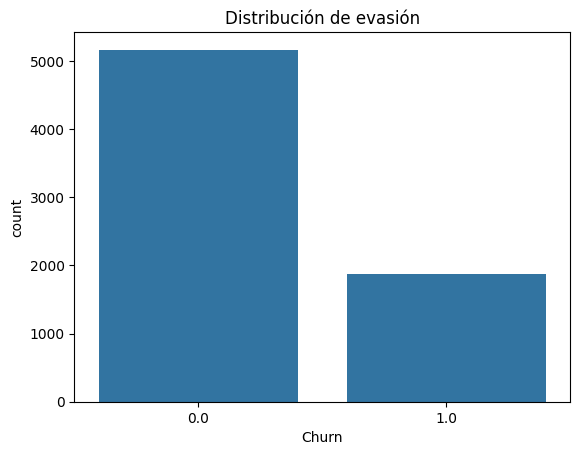

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df_final)

plt.title("Distribución de evasión")
plt.show()

In [22]:
df_final['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


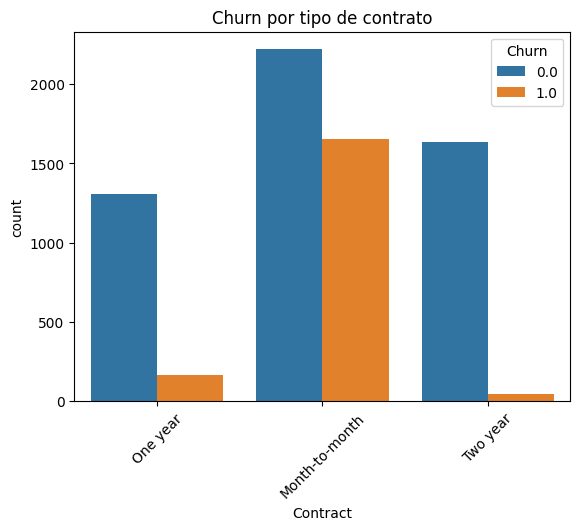

In [23]:
sns.countplot(x='Contract', hue='Churn', data=df_final)

plt.title("Churn por tipo de contrato")
plt.xticks(rotation=45)
plt.show()

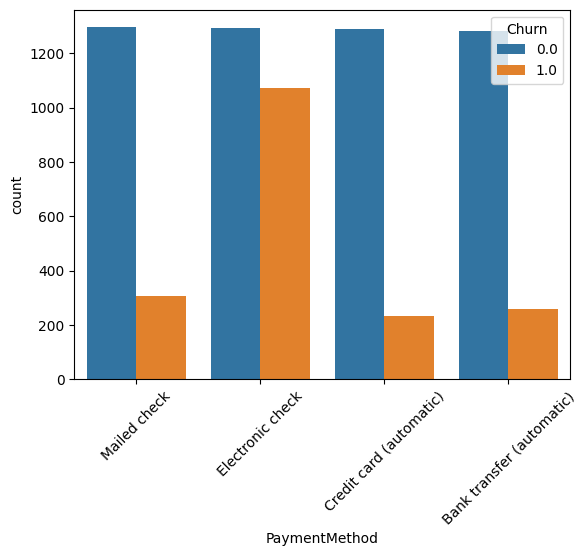

In [24]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df_final)

plt.xticks(rotation=45)
plt.show()

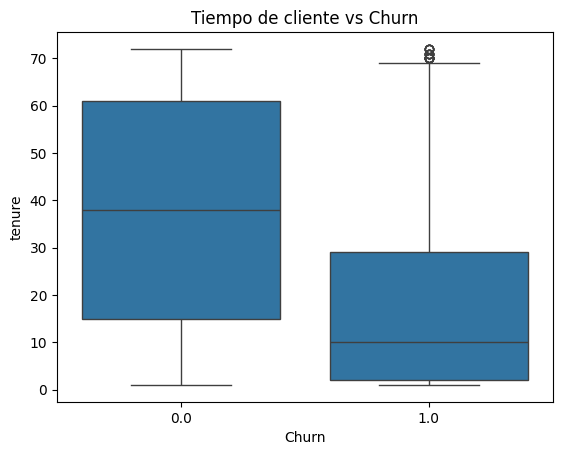

In [25]:
sns.boxplot(x='Churn', y='tenure', data=df_final)

plt.title("Tiempo de cliente vs Churn")
plt.show()

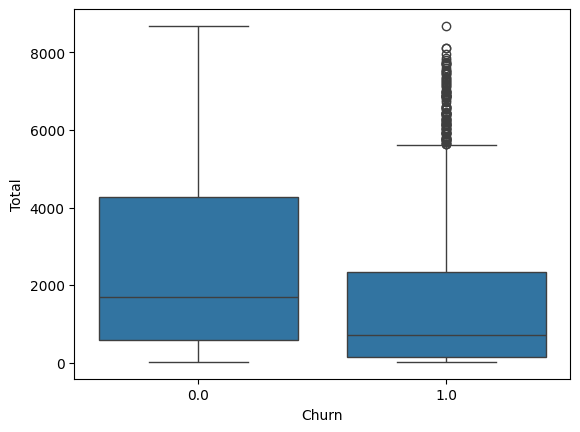

In [26]:
sns.boxplot(x='Churn', y='Total', data=df_final)

plt.show()

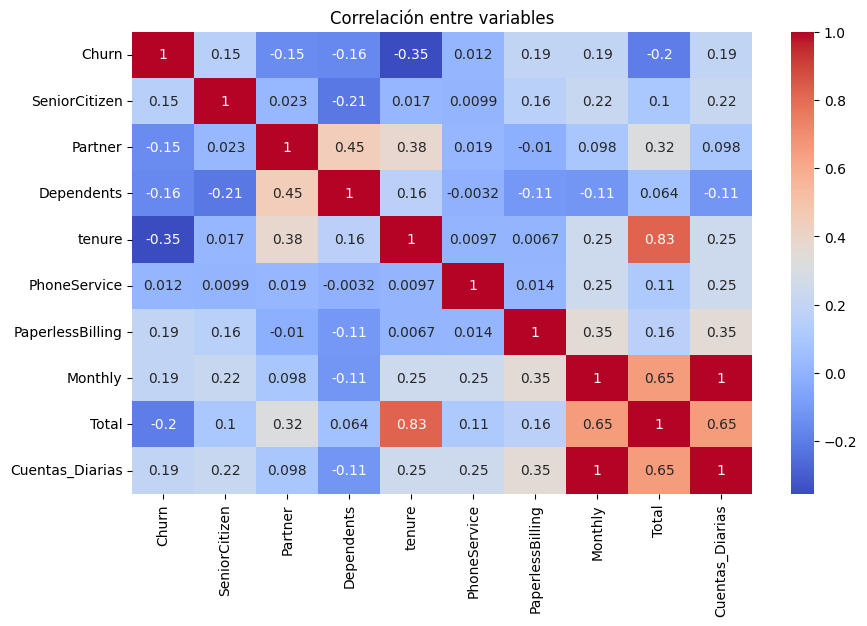

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(df_final.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlación entre variables")
plt.show()

#📄Informe final

1️⃣ Los clientes con contrato mensual presentan mayor tasa de evasión.

2️⃣ Los clientes con menor tiempo (tenure) tienen mayor probabilidad de cancelar.

3️⃣ Los clientes con mayor gasto total tienden a permanecer más tiempo.

4️⃣ Algunos métodos de pago electrónicos presentan mayor churn.